# Valores Atipicos

Es una observacion que es numericamente distante del resto de los datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set(style = 'darkgrid', palette = 'pastel', color_codes = True)
sns.set_context('talk')

# Causas de Valores Atipicos

1. Error de Medicion o de entrada de entadas
2. Datos vengan corruptos desde su origen
3. Realmente sea un valor atipicos (por algun acontecimiento especifico)

# Tipos de Valores Atipicos

1. **Univariante:** Observamos la distribucion de una sola variable
2. **Multivariable:** Son los valores atipicos en un espacio n-dimensional (para encontrarlos, hay que observar la distribucion muldimension)

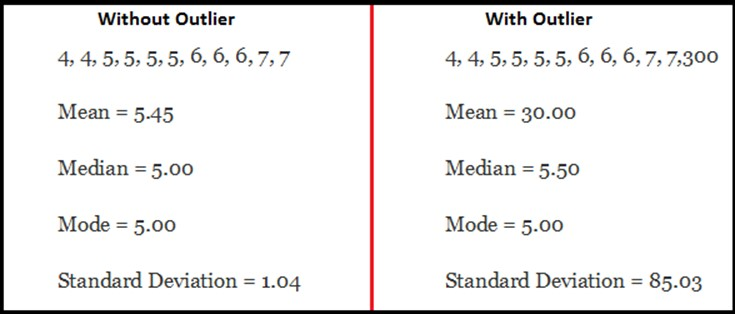

# Tecnicas Deteccion Univariante

In [ ]:
df_1 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/heart.csv')

df_1.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# EDA BASICO

In [ ]:
# Identificar si existen valores nulos

df_1.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [ ]:
# Estadisticas Desrciptiva
df_1.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: ylabel='chol'>

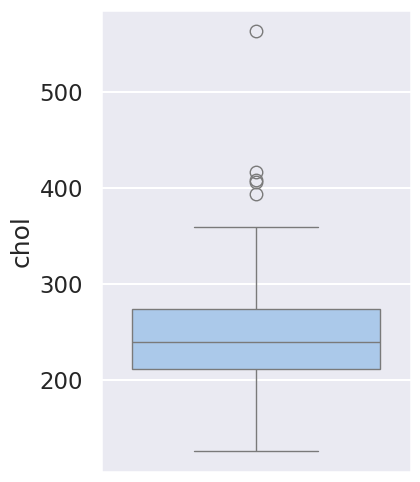

In [ ]:
# Boxplot para ver valores atipicos

plt.figure(figsize = (4, 6))
sns.boxplot(y = df_1.chol)

# 1) Metodo del Rango Intercuartilico

IQR se utiliza para construir graficos de cajas y bigotes. El diagrama mide la dispersion estadistica y la variabilidad de los datos, diviendolos en cuartiles.

IQR = Q3 - Q1

  Limite Superior = Q3 + 1.5 *IQR
  
  Limite Inferior = Q1 - 1.5 *IQR

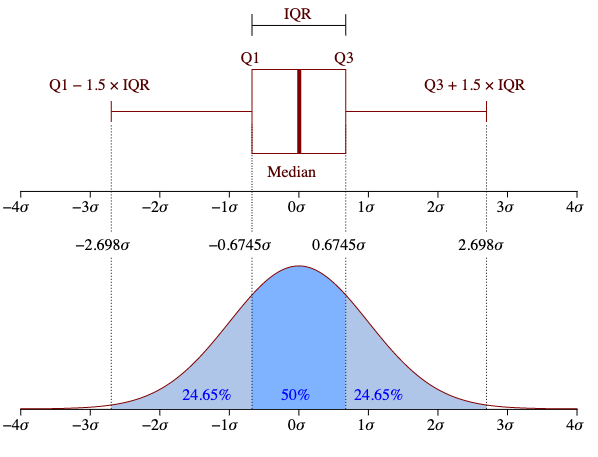

In [ ]:
## Obtener el valor atipico ##

def fuera_rango_iqr (Dataset,columna):
  """ Esta funcion me extrae los valores atipicos del metodo del boxplot """
  global inferior, superior
  Q1, Q3 = np.quantile(Dataset[columna], 0.25), np.quantile(Dataset[columna], 0.75)
  ## Calcular el Rango Intercuartilico ##
  IQR = Q3 - Q1
  # Calcular los cortes atipicos #
  corte_atipico = IQR * 1.5
  inferior, superior = Q1 - corte_atipico, Q3 + corte_atipico
  print('El IQR es: ', IQR)
  print('El limite Inferior es: ', inferior)
  print('El limite Superior es: ', superior)
  #Calcular la cantidad de observaciones en los limites superior e inferiores
  df1 = Dataset[Dataset[columna]>superior]
  df2 = Dataset[Dataset[columna]<inferior]
  return print('Cantidad de valores atipicos es: ', df1.shape[0] + df2.shape[0])


In [ ]:
## Visualizar los valores atupicos de una columna ##

fuera_rango_iqr(df_1,'chol')

El IQR es:  63.5
El limite Inferior es:  115.75
El limite Superior es:  369.75
Cantidad de valores atipicos es:  5


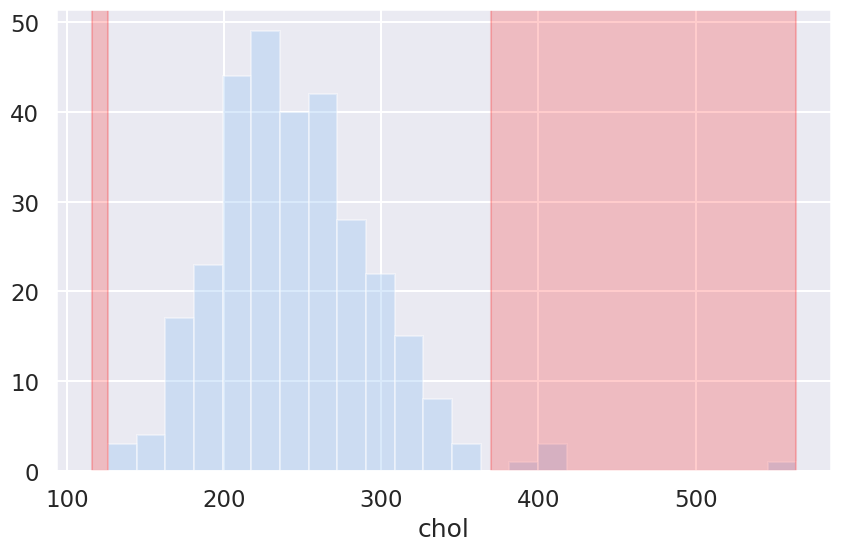

In [ ]:
# Visualizar los valores atipicos #

plt.figure(figsize = (10,6))
sns.distplot(df_1.chol, kde = False)
plt.axvspan(xmin = inferior, xmax = df_1.chol.min(), color = 'red', alpha = 0.2)
plt.axvspan(xmin = superior, xmax = df_1.chol.max(), color = 'red', alpha = 0.2)

In [ ]:
# Filtrar y Eliminar los valores atipicos #

df_new = df_1[np.logical_and(df_1['chol']>inferior, df_1['chol']<superior)]

df_new.shape

(298, 14)

# 2) Metodo de la Desviacion Estandar

Desviacion Estandar es una metrica de varianza, nos dice, cuanto se distribuye los datos individuales con respecto a la media.

En estadistica si una distribucion es normal, podemos decir que el 68% de los datos, se encuentran aproximadamente dentro de una desviacion estandar (izq o derecha), y el 95% de los datos se encuentran dentro de 2 desviaciones estandar y el 99.7% se encuentran dentro de 3 desviaciones estandar.

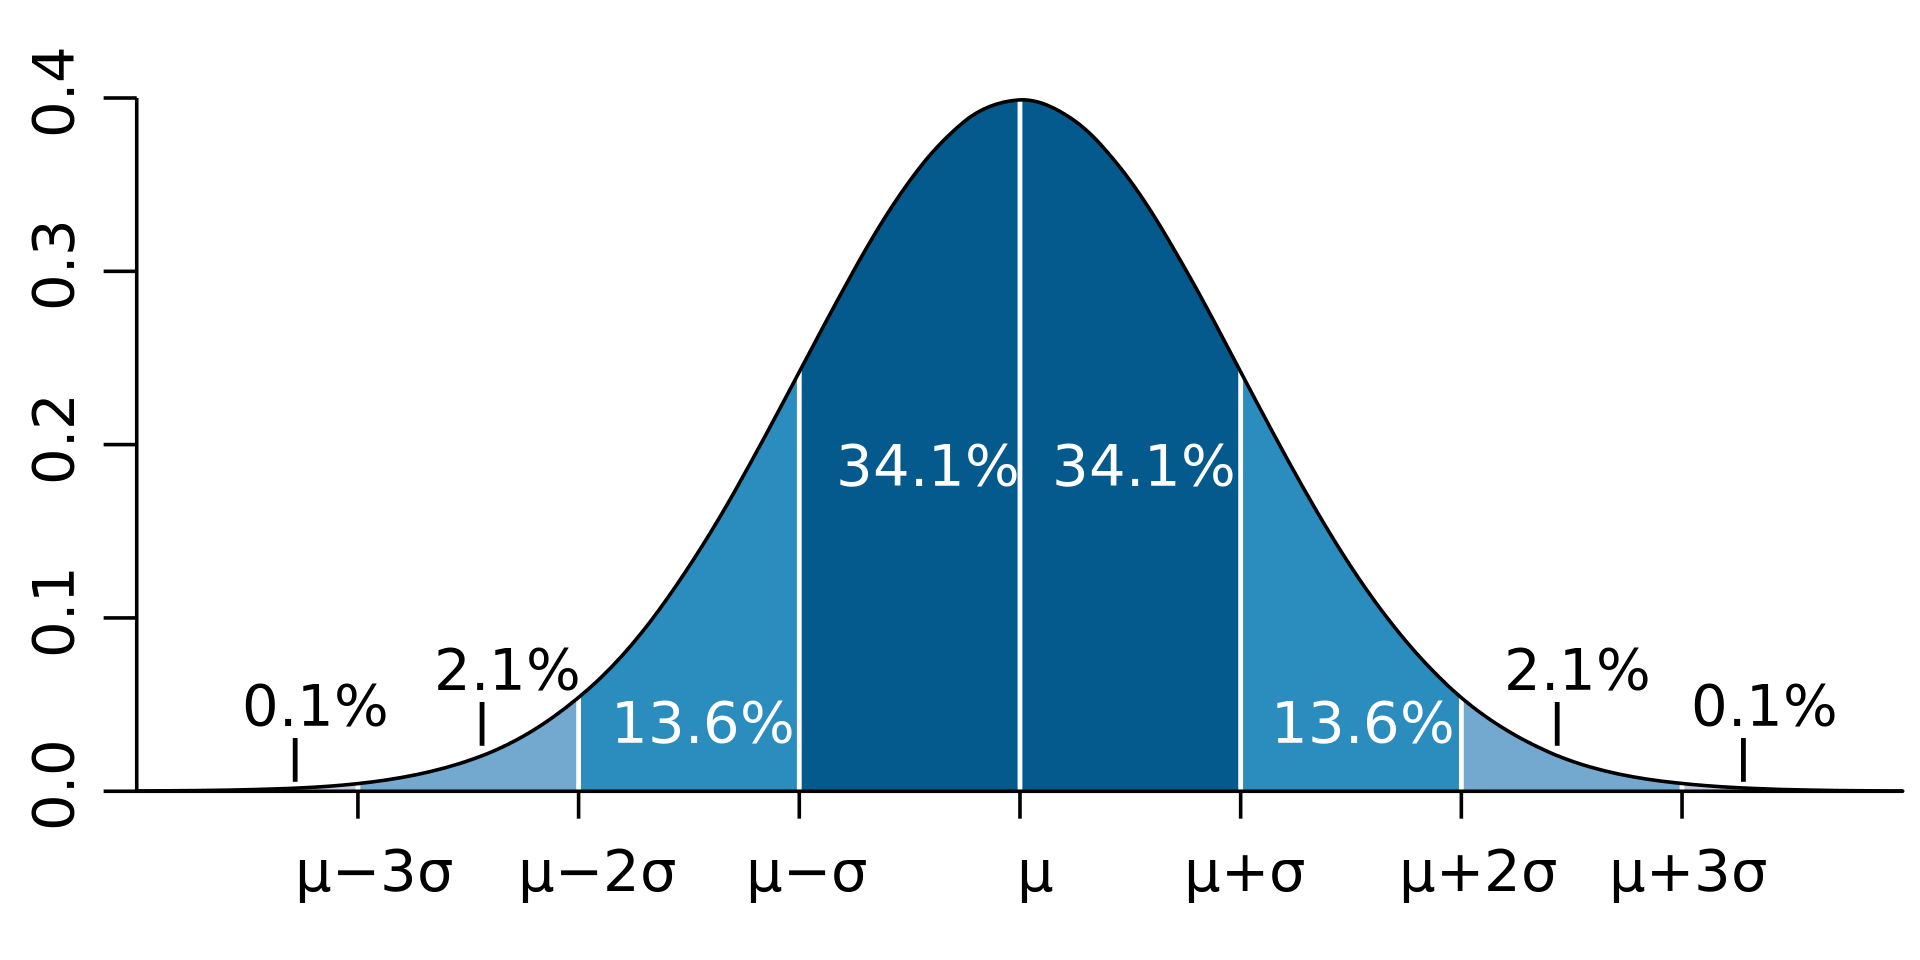

In [ ]:
df_2 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/StudentsPerformance.csv')

df_2.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df_2.shape

(1000, 8)

<Axes: xlabel='writing score', ylabel='Density'>

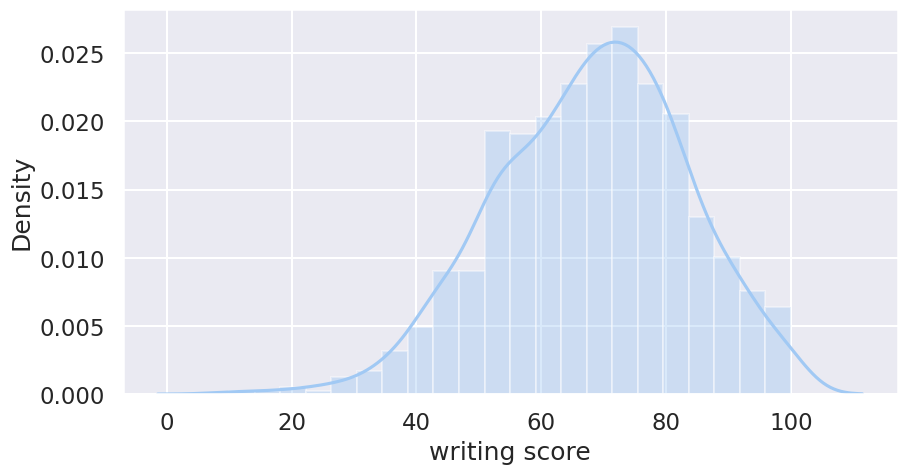

In [ ]:
# Visualizar nuestra variable #

plt.figure(figsize = (10,5))
sns.distplot(df_2['writing score'])

In [ ]:
def fuera_std (dataset,columna):
  """ Esta funcion me extrae los valores atipicos por el metodo desviacion estandar"""
  global inferior_std, superior_std
  ## Calcular la media y la desviacion estandar de la columna en analisis ##
  data_media, data_std = dataset[columna].mean(), dataset[columna].std()
  ## Calcular lo que esta fuera del rango ## k = 3, k =2.5 k = 2
  fuera_del_rango = data_std * 3
  ##Calcular los limites inferiores y superiores ##
  inferior_std, superior_std = data_media - fuera_del_rango, data_media + fuera_del_rango
  print('El limite Inferior es: ', inferior_std)
  print('El limite Superior es: ', superior_std)
  #Calcular la cantidad de observaciones en los limites superior e inferiores
  df1 = dataset[dataset[columna]>superior_std]
  df2 = dataset[dataset[columna]<inferior_std]
  return print('Cantidad de valores atipicos es: ', df1.shape[0] + df2.shape[0])

In [ ]:
fuera_std(df_2, 'writing score')

El limite Inferior es:  22.46702896739105
El limite Superior es:  113.64097103260895
Cantidad de valores atipicos es:  4


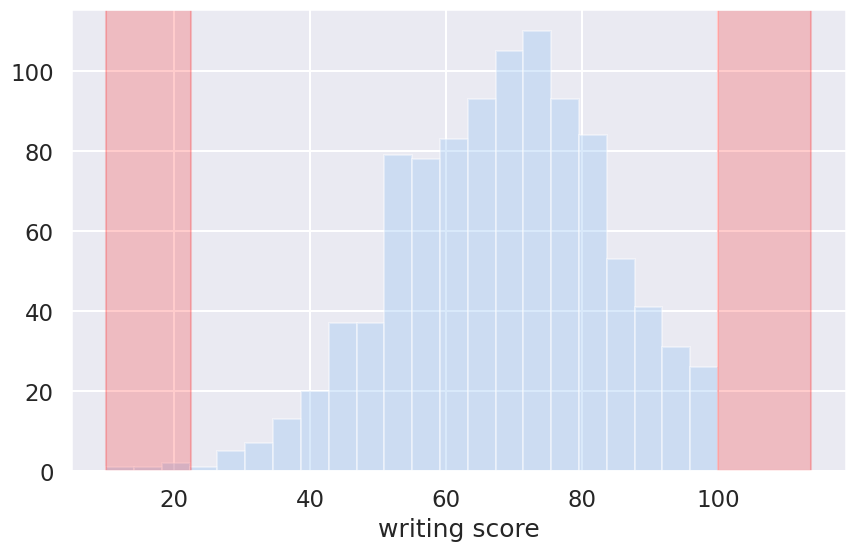

In [ ]:
# Visualizar los valores atipicos #

plt.figure(figsize = (10,6))
sns.distplot(df_2['writing score'], kde = False)
plt.axvspan(xmin = inferior_std, xmax = df_2['writing score'].min(), color = 'red', alpha = 0.2)
plt.axvspan(xmin = superior_std, xmax = df_2['writing score'].max(), color = 'red', alpha = 0.2)

In [ ]:
# Filtrar y Eliminar los valores atipicos #

df_new2 = df_2[np.logical_and(df_2['writing score']>inferior_std, df_2['writing score']<superior_std)]

df_new2.shape

(996, 8)

# 3) Metodo de la Puntuacion Z (Valor Critico)

Esta tecnica ya supone que hay una distribucciones gaussiana o normal.

La puntuacion z es el numero de desviaciones estandar por las cuales el valor de una observacion o punto de datos esta por encima del valor medio de lo que se esta observando.

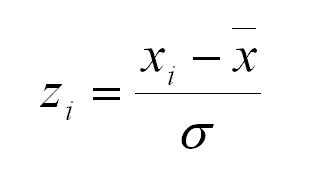

ZTHR = 1.645 , 1.96 2.576


|Valor Z| > ZTHR

In [ ]:
# Cargar los datos #

df_3 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/insurance.csv')

df_3.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='charges', ylabel='Density'>

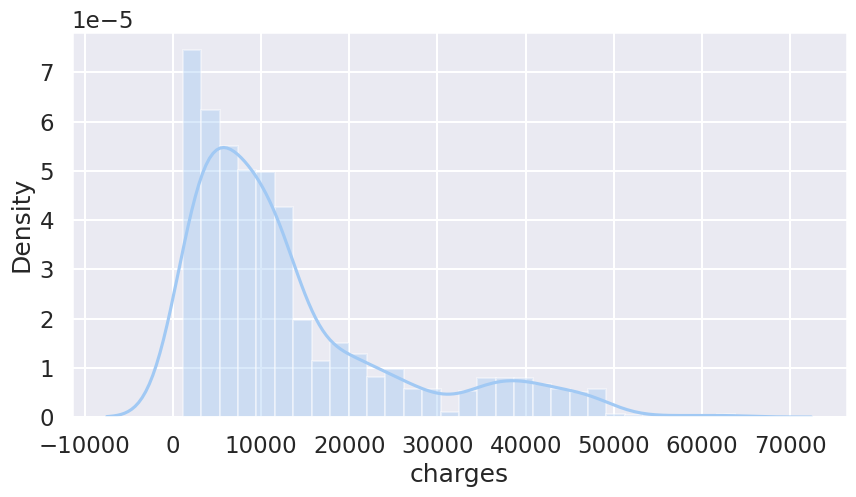

In [ ]:
# Visualizamos la informacion #
plt.figure(figsize = (10,5))
sns.distplot(df_3['charges'])

In [ ]:
def fuera_puntuacion_z (datos):
  """Esta funcion me extrae los valores atipicos apartir de la puntuacion Z"""
  global atipicos, puntuacion_z, limite
  atipicos = []
  puntuacion_z = []
  limite = 1.96 #95% de confianza
  media = np.mean(datos)
  std = np.std(datos)
  for i in datos:
    z = (i-media)/std
    puntuacion_z.append(z)
    if np.abs(z) > limite:
      atipicos.append(i)
  return print('El Total de valores atipicos son: ' ,len(atipicos))

In [ ]:
fuera_puntuacion_z(df_3.charges)

El Total de valores atipicos son:  113


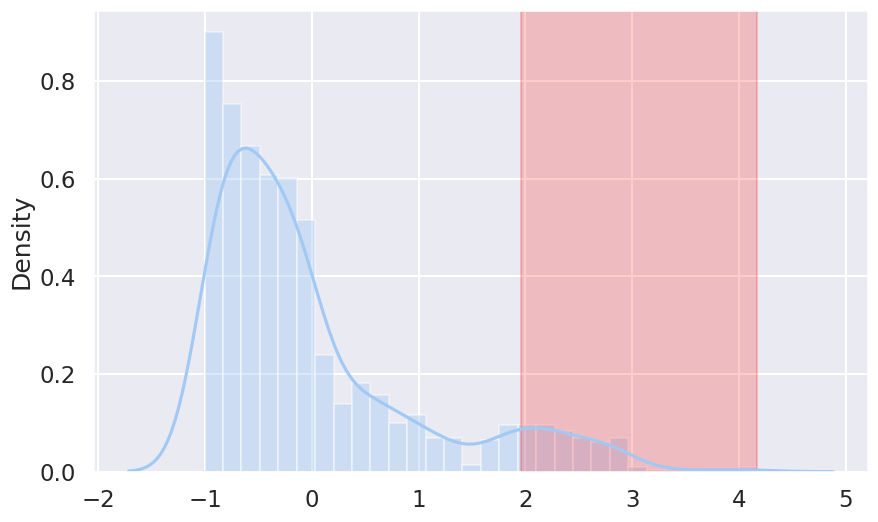

In [ ]:
# Visualizar los valores atipicos #

plt.figure(figsize = (10,6))
sns.distplot(puntuacion_z, kde = True)
plt.axvspan(xmin = limite, xmax = max(puntuacion_z), color = 'red', alpha = 0.2)

In [ ]:
# Filtrar y Eliminar los valores atipicos #

df_new3 = df_3[np.logical_or(df_3['charges']>limite, df_3['charges']<-limite)]

df_new3.shape

(1338, 7)

# 4) Bosque de Aislamiento

Dividir los datos utilizando un conjunto de arboles, con el objetivo de proporcionar una puntuacion de anomalia que se observa que tan aislado esta el punto (valor) en la estructura encontrada.

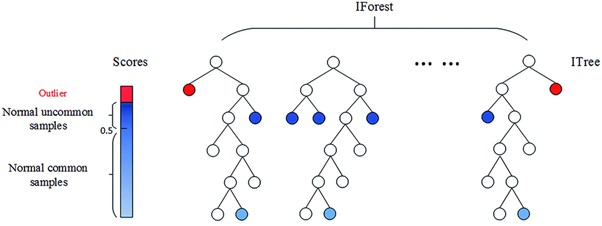

1. El arbol selecciona aleatoriamente un punto "a" para aislar.
2. Luego selecciona un punto aleatorio "b" que esta entre el minimo y el maximo diferentes de "a".
3. Si el valor "b" es inferior al valor de "a" se convierte en mi nuevo limite inferior.
4. Si el valor "b" es mayor que el valor de "a" se convierte en mi nuevo limite superior.
5. Este proceso se repite siempre que haya puntos distintos de "a" entre limite superior e inferior.

In [ ]:
from sklearn.ensemble import IsolationForest


df_4 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/StudentsPerformance.csv')

df_4.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


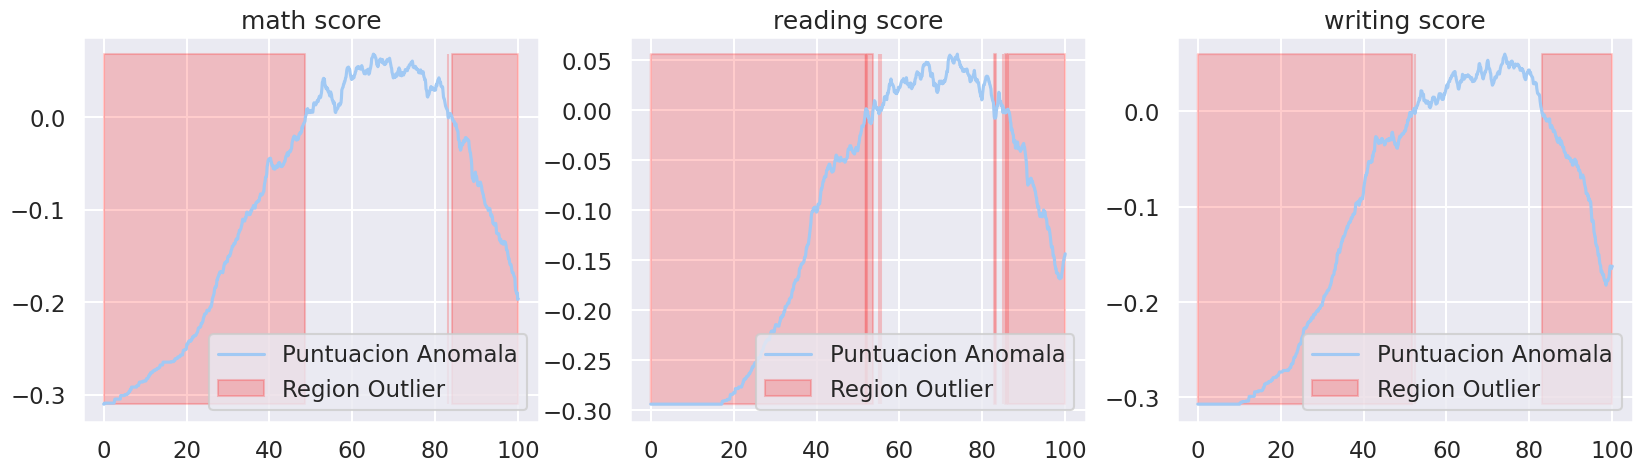

In [ ]:
columna = ['math score','reading score','writing score']

fig, axs = plt.subplots(1,3, figsize = (20,5), facecolor = 'w',edgecolor = 'k')
axs.ravel()

#i = 1
#columna 1 math score
#columna 2 reading score
#columna 3 writing score
#HiperParametro [50,100,200,100]

for i, columns in enumerate(columna):
  isolation_forest = IsolationForest(contamination='auto', random_state=123)
  isolation_forest.fit(df_4[columns].values.reshape(-1,1))

  xx = np.linspace(df_4['math score'].min(),df_4['math score'].max(),len(df_4)).reshape(-1,1)
  puntuacion_anomala = isolation_forest.decision_function(xx)
  outliers = isolation_forest.predict(xx)

  axs[i].plot(xx,puntuacion_anomala, label = 'Puntuacion Anomala')
  axs[i].fill_between(xx.T[0],np.min(puntuacion_anomala), np.max(puntuacion_anomala),
                     where = outliers == -1, color = 'red',
                      alpha = 0.2 , label = 'Region Outlier')
  axs[i].legend()
  axs[i].set_title(columns)

# Valores Atipicos Multivariados

## 1) DBSCAN(Densidad/ Basada en Aplicacion a Cluster Espacial con Ruido)

Es un algoritmo de agrupacion en cluster (alternativa - k-mean), agregar puntos, elementos o valores juntos e identificamos cualquier punto que no pertenezca a un cluster y ese punto es el valor atipico

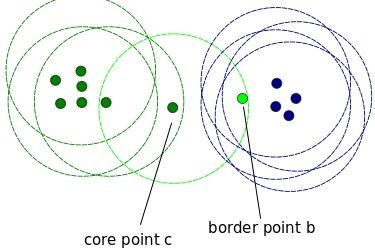

In [ ]:
# Cargar los datos #

df_5 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/insurance.csv')

df_5.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
from sklearn.cluster import DBSCAN

X = df_5[['age','bmi']].values

db = DBSCAN(eps = 3, min_samples = 10).fit(X)
etiquetas = db.labels_

print(etiquetas)

[0 0 0 ... 0 0 0]


In [ ]:
# Visualizamos la cantidad de valores atipicos vrs los normales

pd.Series(etiquetas).value_counts()

 0    1312
-1      26
dtype: int64

-1 representa los valores atipicos que en total son  26

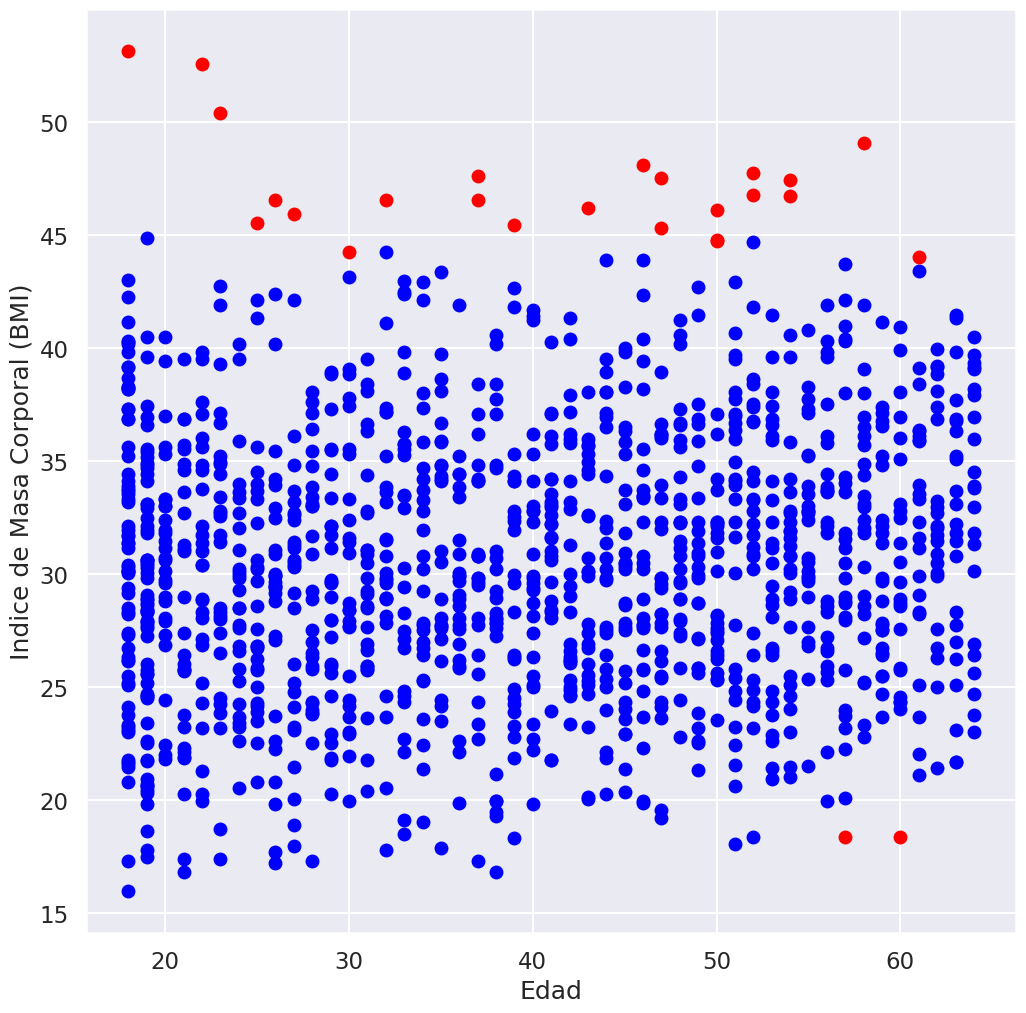

In [ ]:
plt.figure(figsize = (12,12))

valores_unicos = set(etiquetas)
colors = ['blue','red']

for color, etiqueta in zip(colors,valores_unicos):
  mascara = [True if x == etiqueta else False for x in etiquetas ]
  plt.plot(X[:,0][mascara], X[:,1][mascara],'o', color = color)
  plt.xlabel('Edad')
  plt.ylabel('Indice de Masa Corporal (BMI)')

## 2) METODO LOF (Factor Atipico Local)

Identifica valores atipicos basados en la densidad. Identificos los valores atipicos en referencia con lo que pasa con su vecino local.

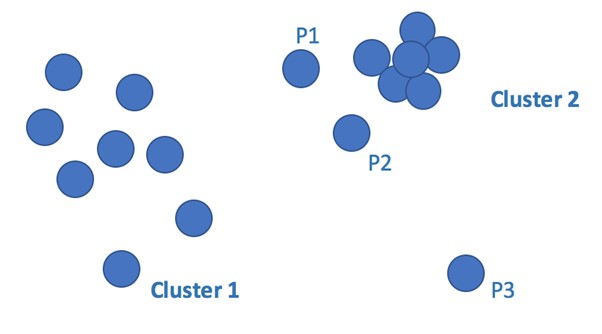

In [ ]:
df_6 = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/heart.csv')

df_6.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
LOF = LocalOutlierFactor(n_neighbors=50, contamination = 'auto')

X_heart = df_6[['age','chol']].values

y_pred_heart = LOF.fit_predict(X_heart)

In [ ]:
y_pred_heart

array([ 1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1

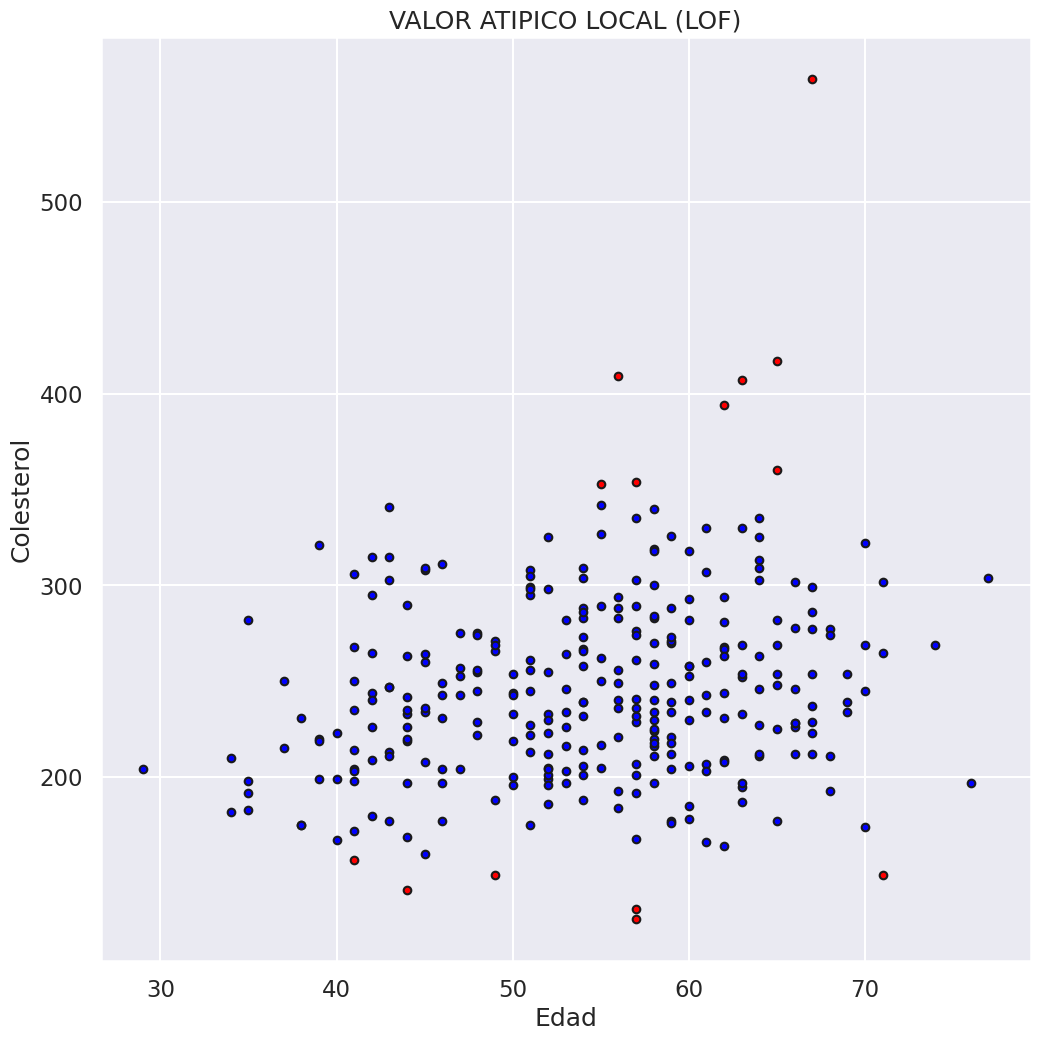

In [ ]:
plt.figure(figsize = (12,12))

dentro_mascara = [True if x == 1 else False for x in y_pred_heart ]
fuera_mascara = [True if x == -1 else False for x in y_pred_heart ]

plt.title('VALOR ATIPICO LOCAL (LOF)')

a = plt.scatter(X_heart[dentro_mascara,0],X_heart[dentro_mascara,1],c = 'blue', edgecolor = 'k', s= 30)
b = plt.scatter(X_heart[fuera_mascara,0],X_heart[fuera_mascara,1],c = 'red', edgecolor = 'k', s= 30)

plt.axis('tight')
plt.xlabel('Edad')
plt.ylabel('Colesterol')
plt.show()